In [2]:
# Check if autoreload is loaded and load/reload accordingly
try:
    %reload_ext autoreload
except Exception:
    %load_ext autoreload
%autoreload 2

# from tqdm.notebook import tqdm

# Basic useful imports
import yaml
from pathlib import Path
import h5py
from cycler import cycler

# Data manipulation
import numpy as np
from scipy.optimize import root_scalar

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

# Clustering stuff
from itertools import cycle
# plt.cm.tab20.colors

# From alens_analysis.py
import alens_analysis.chromatin.chrom_analysis as ca
import alens_analysis.chromatin.chrom_graph_funcs as cgf
from alens_analysis import cluster_analysis as cla

# Locations
ws_path = Path("/home/alamson/DATA/Chromatin/")
mnt_path = Path.home() / "projects/DATA/Chromatin/"
ceph_path = Path.home() / "ceph/DATA/Chromatin/"

image_path = Path("/mnt/home/alamson/papers/dyn_cond_paper/images/")


In [3]:
# Consistent settings
ss_ind = 1
end_ind = None
start_bead = 0
end_bead = None
part_min = 40

# Diffusion time
visc = 1.0 # pN*s/um^2
b_diam = 0.01 # um
kbT = .00411 # pN*um
L_tot = 1600 # beads
L_tot_um = L_tot * b_diam
bead_diff = kbT / (3 * np.pi * visc * b_diam) # um^2/s
diff_time =  b_diam**2 / (6*bead_diff) # s
print(f"Diffusion time: {diff_time:.5f} s")

Diffusion time: 0.00038 s


### Style settings

In [4]:
graph_sty = {
    "axes.titlesize": 20,
    "axes.labelsize": 24,
    "lines.linewidth": 2,
    "lines.markersize": 2,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "font.size": 20,
    "text.usetex": False,
    "mathtext.fontset": "cm",
}
plt.style.use(graph_sty)

colors = cycle(mcolors.XKCD_COLORS.keys())
plt.rcParams["image.cmap"] = "YlOrRd"

def reset_scale(fig, new_width):
    w_old, h_old = fig.get_size_inches()

    fig.set_size_inches(new_width, new_width * h_old / w_old)
    scale = new_width / w_old
    mpl.rcParams["axes.titlesize"] *= scale
    mpl.rcParams["axes.labelsize"] *= scale
    mpl.rcParams["lines.linewidth"] *= scale
    mpl.rcParams["lines.markersize"] *= scale
    mpl.rcParams["xtick.labelsize"] *= scale
    mpl.rcParams["ytick.labelsize"] *= scale
    mpl.rcParams["font.size"] *= scale

# Supplement figures

In [5]:
data_path = (
    ceph_path
    / "DynCondPaper/23-10-17_aLc1_scan8.12_line1600_5umPin_2xKe.1-300/simulations/Ke30/s1/"
)
ss_ind = 1
end_ind = -1
start_bead = 0
n_skip = 10
end_bead = None


with h5py.File(next(data_path.glob("analysis/raw*.h5")), "r+") as h5_data:
    time_arr = h5_data["time"][ss_ind:end_ind:n_skip]

    sy_dat = h5_data["raw_data/sylinders"][
        start_bead:end_bead, :, ss_ind:end_ind:n_skip
    ]
    com_arr = 0.5 * (sy_dat[:, 2:5, :] + sy_dat[:, 5:8, :])

    eps = np.arange(0.005, 0.055, 0.005)
    min_sample = np.arange(4, 52, 2)
    clust_num_mat = np.zeros((eps.size, min_sample.size))
    beads_in_clust_mat = np.zeros((eps.size, min_sample.size))
    avg_bead_per_clust_mat = np.zeros((eps.size, min_sample.size))
    avg_rog_mat = np.zeros((eps.size, min_sample.size))
    for i, e in enumerate(eps):
        for j, m in enumerate(min_sample):
            print(f"i={i}, j={j}")
            clust, cluster_centers, cluster_label_inds = cla.identify_spatial_clusters(
                com_arr[:, :, -1], eps=e, min_samples=m, thresh=40, verbose=False
            )
            clust_num_mat[i, j] = len(cluster_centers)
            if clust_num_mat[i, j] == 0:
                beads_in_clust_mat[i, j] = 0
                avg_bead_per_clust_mat[i, j] = 0
                avg_rog_mat[i, j] = np.nan
                continue
            beads_in_clust_mat[i, j] = sum([len(cli) for cli in cluster_label_inds])
            avg_bead_per_clust_mat[i, j] = np.mean(
                [len(cli) for cli in cluster_label_inds]
            )
            avg_rog_mat[i, j] = np.mean(
                [
                    ca.calc_rad_of_gyration(com_arr[cli, :, end_ind, np.newaxis])
                    / np.cbrt(len(cli))
                    for cli in cluster_label_inds
                ]
            )


i=0, j=0
i=0, j=1
i=0, j=2
i=0, j=3
i=0, j=4
i=0, j=5
i=0, j=6
i=0, j=7
i=0, j=8
i=0, j=9
i=0, j=10
i=0, j=11
i=0, j=12
i=0, j=13
i=0, j=14
i=0, j=15
i=0, j=16
i=0, j=17
i=0, j=18
i=0, j=19
i=0, j=20
i=0, j=21
i=0, j=22
i=0, j=23
i=1, j=0
i=1, j=1
i=1, j=2
i=1, j=3
i=1, j=4
i=1, j=5
i=1, j=6
i=1, j=7
i=1, j=8
i=1, j=9
i=1, j=10
i=1, j=11
i=1, j=12
i=1, j=13
i=1, j=14
i=1, j=15
i=1, j=16
i=1, j=17
i=1, j=18
i=1, j=19
i=1, j=20
i=1, j=21
i=1, j=22
i=1, j=23
i=2, j=0
i=2, j=1
i=2, j=2
i=2, j=3
i=2, j=4
i=2, j=5
i=2, j=6
i=2, j=7
i=2, j=8
i=2, j=9
i=2, j=10
i=2, j=11
i=2, j=12
i=2, j=13
i=2, j=14
i=2, j=15
i=2, j=16
i=2, j=17
i=2, j=18
i=2, j=19
i=2, j=20
i=2, j=21
i=2, j=22
i=2, j=23
i=3, j=0
i=3, j=1
i=3, j=2
i=3, j=3
i=3, j=4
i=3, j=5
i=3, j=6
i=3, j=7
i=3, j=8
i=3, j=9
i=3, j=10
i=3, j=11
i=3, j=12
i=3, j=13
i=3, j=14
i=3, j=15
i=3, j=16
i=3, j=17
i=3, j=18
i=3, j=19
i=3, j=20
i=3, j=21
i=3, j=22
i=3, j=23
i=4, j=0
i=4, j=1
i=4, j=2
i=4, j=3
i=4, j=4
i=4, j=5
i=4, j=6
i=4, j=7
i=4, j=8

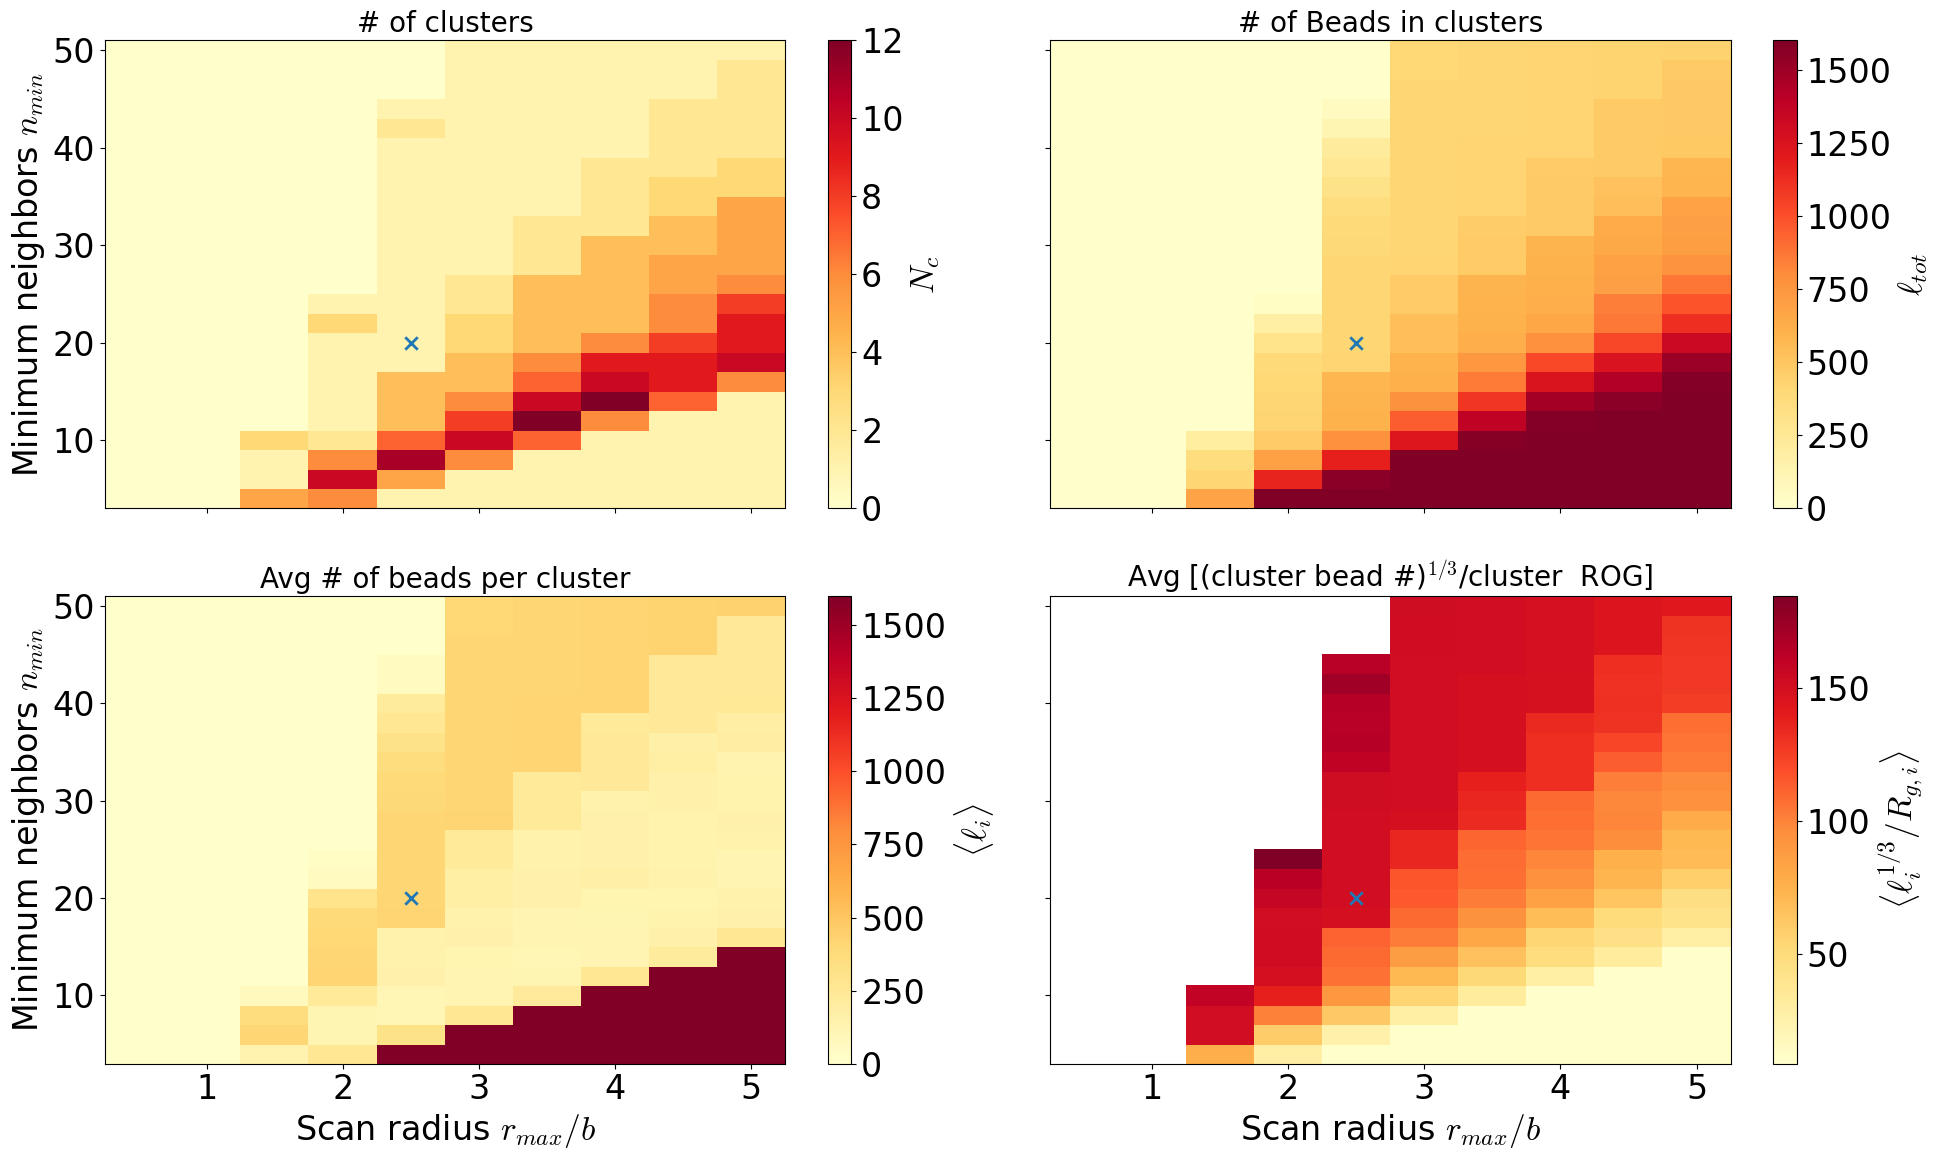

In [6]:
fig, axarr = plt.subplots(2, 2, figsize=(20, 12), sharex=True, sharey=True)
axarr = axarr.flatten()

X, Y = np.meshgrid(
    np.append(eps, 0.055) - 0.0025, np.append(min_sample, 52) - 1
)  # Shift edges of the bins to center the values
X /= b_diam
c0 = axarr[0].pcolor(X, Y, clust_num_mat.T)
c1 = axarr[1].pcolor(X, Y, beads_in_clust_mat.T)
c2 = axarr[2].pcolor(X, Y, avg_bead_per_clust_mat.T)
c3 = axarr[3].pcolor(X, Y, 1 / avg_rog_mat.T)
cbar0 = fig.colorbar(c0, ax=axarr[0], label="$N_c$")
cbar1 = fig.colorbar(c1, ax=axarr[1], label=r"$\ell_{tot}$")
cbar2 = fig.colorbar(c2, ax=axarr[2], label=r"$\langle \ell_i \rangle$")
cbar3 = fig.colorbar(c3, ax=axarr[3], label=r"$\langle \ell_i^{1/3}/R_{g,i} \rangle$")
_ = axarr[0].set_title("# of clusters")
_ = axarr[1].set_title("# of Beads in clusters")
_ = axarr[2].set_title("Avg # of beads per cluster")
_ = axarr[3].set_title("Avg [(cluster bead #)$^{1/3}$/cluster  ROG]")
for ax in axarr:
    _ = ax.scatter(0.025/b_diam, 20, s=80, marker="x")

_ = axarr[0].set_ylabel("Minimum neighbors $n_{min}$")
_ = axarr[2].set_ylabel("Minimum neighbors $n_{min}$")
_ = axarr[2].set_xlabel("Scan radius $r_{max}/b$")
_ = axarr[3].set_xlabel("Scan radius $r_{max}/b$")

plt.tight_layout()

fig.savefig("SFig_dbscan_param_search/sfig_dbscan_param_search.pdf", dpi=600, bbox_inches="tight")
fig.savefig("SFig_dbscan_param_search/sfig_dbscan_param_search.eps", dpi=600, bbox_inches="tight")
fig.savefig("SFig_dbscan_param_search/sfig_dbscan_param_search.png", dpi=600, bbox_inches="tight")
fig.savefig(image_path / "sfig_dbscan_param_search.png", dpi=600, bbox_inches="tight",)
fig.savefig(image_path / "sfig_dbscan_param_search.eps", dpi=600, bbox_inches="tight",)
fig.savefig(image_path / "sfig_dbscan_param_search.pdf", dpi=600, bbox_inches="tight",)
